In [35]:
import pandas as pd
pd.set_option("display.max_rows", 200)   # show all rows
pd.set_option("display.max_columns", 200) # show all columns

def move_column(df, col_name, new_position):
    assert col_name in df.columns, "Column not found in DataFrame"
    assert 0 <= new_position < len(df.columns), "New position out of bounds"
    cols = df.columns.tolist()
    cols.insert(new_position, cols.pop(cols.index(col_name)))
    return df[cols]

from typing import Any, Dict, Iterable, Iterator, Tuple, Callable, Optional
import pandas as pd
from copy import deepcopy

class DFStruct:
    def __init__(self, drop_for_training: Optional[Iterable[str]] = None):
        self._store: Dict[Tuple[Tuple[str, Any], ...], pd.DataFrame] = {}
        # Default columns to drop for training
        self._train_exclude = set(drop_for_training or
                                  ["OASISID", "seg_days", "cdr_days", "delta_days", "CDRTOT"])

    # ---------- internals ----------
    def _norm_key(self, kwargs: Dict[str, Any]) -> Tuple[Tuple[str, Any], ...]:
        return tuple(sorted(kwargs.items()))

    def _drop_cols(self, df: pd.DataFrame, extra_drop: Optional[Iterable[str]] = None) -> pd.DataFrame:
        cols = self._train_exclude.union(extra_drop or [])
        # errors='ignore' so missing columns don't raise
        return df.drop(columns=list(cols), errors="ignore")

    # ---------- core API ----------
    def __call__(self, **kwargs) -> pd.DataFrame:
        """Retrieve a dataframe by its flags."""
        return self._store[self._norm_key(kwargs)]

    def add(self, df: pd.DataFrame, **kwargs) -> None:
        """Add a dataframe with its flags."""
        self._store[self._norm_key(kwargs)] = df

    def filter(self, **kwargs) -> Iterator[Tuple[Tuple[Tuple[str, Any], ...], pd.DataFrame]]:
        """Iterate over (key, df) where flags match kwargs."""
        for key, df in self._store.items():
            if all(item in dict(key).items() for item in kwargs.items()):
                yield key, df

    def apply(self, func: Callable[[pd.DataFrame], pd.DataFrame], **kwargs) -> None:
        """Apply func to all dfs matching kwargs (in place)."""
        for key, df in self.filter(**kwargs):
            self._store[key] = func(df)

    # ---------- training helpers ----------
    def get_for_training(
        self,
        * ,
        extra_drop: Optional[Iterable[str]] = None,
        copy_df: bool = True,
        **kwargs
    ) -> pd.DataFrame:
        """
        Retrieve a dataframe (by flags) with training-excluded columns dropped.

        Parameters
        ----------
        extra_drop : extra column names to drop in addition to default list
        copy_df    : return a copy before dropping (default True, keeps store unchanged)
        **kwargs   : the flags selecting the stored df
        """
        df = self(**kwargs)
        df = df.copy(deep=True) if copy_df else df
        return self._drop_cols(df, extra_drop=extra_drop)

    def prepare_for_training_inplace(
        self,
        * ,
        extra_drop: Optional[Iterable[str]] = None,
        **kwargs
    ) -> None:
        """
        Drop training-excluded columns IN PLACE for all dfs matching flags.
        Useful if you want the stored versions to be stripped before training.
        """
        def _strip(d: pd.DataFrame) -> pd.DataFrame:
            return self._drop_cols(d, extra_drop=extra_drop)
        self.apply(_strip, **kwargs)

    def set_training_drop_columns(self, cols: Iterable[str]) -> None:
        """Replace the default training-excluded columns."""
        self._train_exclude = set(cols)

    def add_training_drop_columns(self, cols: Iterable[str]) -> None:
        """Add to the default training-excluded columns."""
        self._train_exclude.update(cols)

    def keys_raw(self) -> list[tuple[tuple[str, Any], ...]]:
        return list(self._store.keys())

    def keys_dict(self) -> list[dict[str, Any]]:
        return [dict(k) for k in self._store.keys()]

    def flag_space(self) -> dict[str, set]:
        out: dict[str, set] = {}
        for k in self._store.keys():
            for name, val in k:
                out.setdefault(name, set()).add(val)
        return out


# Segmentation csv

In [36]:
seg3 = pd.read_csv("./data/OASIS3/SUM_GM.csv")
seg3_thrs = pd.read_csv("./data/OASIS3/SUM_thrs_GM.csv")
seg4 = pd.read_csv("./data/OASIS4/Atlas_proj_summary/SUM_GM.csv")
seg4_thrs = pd.read_csv("./data/OASIS4/Atlas_proj_summary/SUM_thrs_GM.csv")

In [37]:
overlap = set(seg3['PR_number']).intersection(seg4['PR_number'])
print("Not thresholded :")
if overlap:
    print("Not mutually exclusive. Overlap found:", overlap)
else:
    print("Mutually exclusive. No overlap.")

overlap = set(seg3_thrs['PR_number']).intersection(seg4_thrs['PR_number'])
print("Thresholded :")
if overlap:
    print("Not mutually exclusive. Overlap found:", overlap)
else:
    print("Mutually exclusive. No overlap.")


Not thresholded :
Mutually exclusive. No overlap.
Thresholded :
Mutually exclusive. No overlap.


In [38]:
seg = pd.concat([seg3, seg4], ignore_index=True)
seg_thrs = pd.concat([seg3_thrs, seg4_thrs], ignore_index=True)

In [39]:
seg #1264 subjects x 166 ROIs

,PR_number,session,run,TIV,x3rdVentricle,x4thVentricle,RightAccumbensArea,LeftAccumbensArea,BrainStem,RightCaudate,LeftCaudate,RightCerebellumExterior,LeftCerebellumExterior,RightCerebralWhiteMatter,LeftCerebralWhiteMatter,CSF,RightInfLatVent,LeftInfLatVent,RightLateralVentricle,LeftLateralVentricle,RightPallidum,LeftPallidum,RightPutamen,LeftPutamen,RightVessel,LeftVessel,OpticChiasm,CerebellarVermalLobulesI0x2DV,CerebellarVermalLobulesVI0x2DVII,CerebellarVermalLobulesVIII0x2DX,LeftBasalForebrain,RightBasalForebrain,RightACgGAnteriorCingulateGyrus,LeftACgGAnteriorCingulateGyrus,RightAInsAnteriorInsula,LeftAInsAnteriorInsula,RightAOrGAnteriorOrbitalGyrus,LeftAOrGAnteriorOrbitalGyrus,RightAnGAngularGyrus,LeftAnGAngularGyrus,RightCalcCalcarineCortex,LeftCalcCalcarineCortex,RightCOCentralOperculum,LeftCOCentralOperculum,RightCunCuneus,LeftCunCuneus,RightEntEntorhinalArea,LeftEntEntorhinalArea,RightFOFrontalOperculum,LeftFOFrontalOperculum,RightFRPFrontalPole,LeftFRPFrontalPole,RightFuGFusiformGyrus,LeftFuGFusiformGyrus,RightGReGyrusRectus,LeftGReGyrusRectus,RightIOGInferiorOccipitalGyrus,LeftIOGInferiorOccipitalGyrus,RightITGInferiorTemporalGyrus,LeftITGInferiorTemporalGyrus,RightLiGLingualGyrus,LeftLiGLingualGyrus,RightLOrGLateralOrbitalGyrus,LeftLOrGLateralOrbitalGyrus,RightMCgGMiddleCingulateGyrus,LeftMCgGMiddleCingulateGyrus,RightMFCMedialFrontalCortex,LeftMFCMedialFrontalCortex,RightMFGMiddleFrontalGyrus,LeftMFGMiddleFrontalGyrus,RightMOGMiddleOccipitalGyrus,LeftMOGMiddleOccipitalGyrus,RightMOrGMedialOrbitalGyrus,LeftMOrGMedialOrbitalGyrus,RightMPoGPostcentralGyrusMedialSegment,LeftMPoGPostcentralGyrusMedialSegment,RightMPrGPrecentralGyrusMedialSegment,LeftMPrGPrecentralGyrusMedialSegment,RightMSFGSuperiorFrontalGyrusMedialSegment,LeftMSFGSuperiorFrontalGyrusMedialSegment,RightMTGMiddleTemporalGyrus,LeftMTGMiddleTemporalGyrus,RightOCPOccipitalPole,LeftOCPOccipitalPole,RightOFuGOccipitalFusiformGyrus,LeftOFuGOccipitalFusiformGyrus,RightOpIFGOpercularPartOfTheInferiorFrontalGyrus,LeftOpIFGOpercularPartOfTheInferiorFrontalGyrus,RightOrIFGOrbitalPartOfTheInferiorFrontalGyrus,LeftOrIFGOrbitalPartOfTheInferiorFrontalGyrus,RightPCgGPosteriorCingulateGyrus,LeftPCgGPosteriorCingulateGyrus,RightPCuPrecuneus,LeftPCuPrecuneus,RightPHGParahippocampalGyrus,LeftPHGParahippocampalGyrus,RightPInsPosteriorInsula,LeftPInsPosteriorInsula,RightPOParietalOperculum,LeftPOParietalOperculum,RightPoGPostcentralGyrus,LeftPoGPostcentralGyrus,RightPOrGPosteriorOrbitalGyrus,LeftPOrGPosteriorOrbitalGyrus,RightPPPlanumPolare,LeftPPPlanumPolare,RightPrGPrecentralGyrus,LeftPrGPrecentralGyrus,RightPTPlanumTemporale,LeftPTPlanumTemporale,RightSCASubcallosalArea,LeftSCASubcallosalArea,RightSFGSuperiorFrontalGyrus,LeftSFGSuperiorFrontalGyrus,RightSMCSupplementaryMotorCortex,LeftSMCSupplementaryMotorCortex,RightSMGSupramarginalGyrus,LeftSMGSupramarginalGyrus,RightSOGSuperiorOccipitalGyrus,LeftSOGSuperiorOccipitalGyrus,RightSPLSuperiorParietalLobule,LeftSPLSuperiorParietalLobule,RightSTGSuperiorTemporalGyrus,LeftSTGSuperiorTemporalGyrus,RightTMPTemporalPole,LeftTMPTemporalPole,RightTrIFGTriangularPartOfTheInferiorFrontalGyrus,LeftTrIFGTriangularPartOfTheInferiorFrontalGyrus,RightTTGTransverseTemporalGyrus,LeftTTGTransverseTemporalGyrus,LeftSTN,RightSTN,LeftSubstantiaNigra,RightSubstantiaNigra,LeftRedNucleus,RightRedNucleus,LeftDentateNucleus,RightDentateNucleus,LeftTh_anterior,RightTh_anterior,LeftTh_geniculate,RightTh_geniculate,LeftTh_mediodorsal,RightTh_mediodorsal,LeftTh_intralaminar,RightTh_intralaminar,LeftTh_pulvinar,RightTh_pulvinar,LeftTh_ventroanterior,RightTh_ventroanterior,LeftTh_ventrolateral,RightTh_ventrolateral,LeftTh_ventroposterior,RightTh_ventroposterior,LeftTh_posteriorAnterior,RightTh_posteriorAnterior,LeftAgd_astr,RightAgd_astr,LeftAgd_centromedian,RightAgd_centromedian,LeftAgd_laterobasal,RightAgd_laterobasal,LeftAgd_superficial,RightAgd_superficial,LeftHi_SPAM_CA10x2D3,RightHi_SPAM_CA10x2D3,LeftHi_SPAM_CA40x2DDG,RightHi_SPAM_CA40x2DDG,LeftH

In [40]:
print(seg["PR_number"].nunique())
print(seg_thrs["PR_number"].nunique())

2036
2036


In [41]:
#seg.isna().sum().sort_values(ascending=False)

In [42]:
def preprocess_seg(df):
    df['days'] = df['session'].str.extract(r'(\d+)').astype(int)
    df = move_column(df, "days", 2)

    df["OASISID"] = df["PR_number"].str.replace("sub-", "")

    df = move_column(df, "OASISID", 0)

    df = df.drop(columns=['session', 'run', 'PR_number'])
    return df
seg = preprocess_seg(seg)
seg_thrs = preprocess_seg(seg_thrs)

/tmp/ipykernel_273630/1814607859.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["OASISID"] = df["PR_number"].str.replace("sub-", "")
/tmp/ipykernel_273630/1814607859.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["OASISID"] = df["PR_number"].str.replace("sub-", "")


In [43]:
seg

,OASISID,days,TIV,x3rdVentricle,x4thVentricle,RightAccumbensArea,LeftAccumbensArea,BrainStem,RightCaudate,LeftCaudate,RightCerebellumExterior,LeftCerebellumExterior,RightCerebralWhiteMatter,LeftCerebralWhiteMatter,CSF,RightInfLatVent,LeftInfLatVent,RightLateralVentricle,LeftLateralVentricle,RightPallidum,LeftPallidum,RightPutamen,LeftPutamen,RightVessel,LeftVessel,OpticChiasm,CerebellarVermalLobulesI0x2DV,CerebellarVermalLobulesVI0x2DVII,CerebellarVermalLobulesVIII0x2DX,LeftBasalForebrain,RightBasalForebrain,RightACgGAnteriorCingulateGyrus,LeftACgGAnteriorCingulateGyrus,RightAInsAnteriorInsula,LeftAInsAnteriorInsula,RightAOrGAnteriorOrbitalGyrus,LeftAOrGAnteriorOrbitalGyrus,RightAnGAngularGyrus,LeftAnGAngularGyrus,RightCalcCalcarineCortex,LeftCalcCalcarineCortex,RightCOCentralOperculum,LeftCOCentralOperculum,RightCunCuneus,LeftCunCuneus,RightEntEntorhinalArea,LeftEntEntorhinalArea,RightFOFrontalOperculum,LeftFOFrontalOperculum,RightFRPFrontalPole,LeftFRPFrontalPole,RightFuGFusiformGyrus,LeftFuGFusiformGyrus,RightGReGyrusRectus,LeftGReGyrusRectus,RightIOGInferiorOccipitalGyrus,LeftIOGInferiorOccipitalGyrus,RightITGInferiorTemporalGyrus,LeftITGInferiorTemporalGyrus,RightLiGLingualGyrus,LeftLiGLingualGyrus,RightLOrGLateralOrbitalGyrus,LeftLOrGLateralOrbitalGyrus,RightMCgGMiddleCingulateGyrus,LeftMCgGMiddleCingulateGyrus,RightMFCMedialFrontalCortex,LeftMFCMedialFrontalCortex,RightMFGMiddleFrontalGyrus,LeftMFGMiddleFrontalGyrus,RightMOGMiddleOccipitalGyrus,LeftMOGMiddleOccipitalGyrus,RightMOrGMedialOrbitalGyrus,LeftMOrGMedialOrbitalGyrus,RightMPoGPostcentralGyrusMedialSegment,LeftMPoGPostcentralGyrusMedialSegment,RightMPrGPrecentralGyrusMedialSegment,LeftMPrGPrecentralGyrusMedialSegment,RightMSFGSuperiorFrontalGyrusMedialSegment,LeftMSFGSuperiorFrontalGyrusMedialSegment,RightMTGMiddleTemporalGyrus,LeftMTGMiddleTemporalGyrus,RightOCPOccipitalPole,LeftOCPOccipitalPole,RightOFuGOccipitalFusiformGyrus,LeftOFuGOccipitalFusiformGyrus,RightOpIFGOpercularPartOfTheInferiorFrontalGyrus,LeftOpIFGOpercularPartOfTheInferiorFrontalGyrus,RightOrIFGOrbitalPartOfTheInferiorFrontalGyrus,LeftOrIFGOrbitalPartOfTheInferiorFrontalGyrus,RightPCgGPosteriorCingulateGyrus,LeftPCgGPosteriorCingulateGyrus,RightPCuPrecuneus,LeftPCuPrecuneus,RightPHGParahippocampalGyrus,LeftPHGParahippocampalGyrus,RightPInsPosteriorInsula,LeftPInsPosteriorInsula,RightPOParietalOperculum,LeftPOParietalOperculum,RightPoGPostcentralGyrus,LeftPoGPostcentralGyrus,RightPOrGPosteriorOrbitalGyrus,LeftPOrGPosteriorOrbitalGyrus,RightPPPlanumPolare,LeftPPPlanumPolare,RightPrGPrecentralGyrus,LeftPrGPrecentralGyrus,RightPTPlanumTemporale,LeftPTPlanumTemporale,RightSCASubcallosalArea,LeftSCASubcallosalArea,RightSFGSuperiorFrontalGyrus,LeftSFGSuperiorFrontalGyrus,RightSMCSupplementaryMotorCortex,LeftSMCSupplementaryMotorCortex,RightSMGSupramarginalGyrus,LeftSMGSupramarginalGyrus,RightSOGSuperiorOccipitalGyrus,LeftSOGSuperiorOccipitalGyrus,RightSPLSuperiorParietalLobule,LeftSPLSuperiorParietalLobule,RightSTGSuperiorTemporalGyrus,LeftSTGSuperiorTemporalGyrus,RightTMPTemporalPole,LeftTMPTemporalPole,RightTrIFGTriangularPartOfTheInferiorFrontalGyrus,LeftTrIFGTriangularPartOfTheInferiorFrontalGyrus,RightTTGTransverseTemporalGyrus,LeftTTGTransverseTemporalGyrus,LeftSTN,RightSTN,LeftSubstantiaNigra,RightSubstantiaNigra,LeftRedNucleus,RightRedNucleus,LeftDentateNucleus,RightDentateNucleus,LeftTh_anterior,RightTh_anterior,LeftTh_geniculate,RightTh_geniculate,LeftTh_mediodorsal,RightTh_mediodorsal,LeftTh_intralaminar,RightTh_intralaminar,LeftTh_pulvinar,RightTh_pulvinar,LeftTh_ventroanterior,RightTh_ventroanterior,LeftTh_ventrolateral,RightTh_ventrolateral,LeftTh_ventroposterior,RightTh_ventroposterior,LeftTh_posteriorAnterior,RightTh_posteriorAnterior,LeftAgd_astr,RightAgd_astr,LeftAgd_centromedian,RightAgd_centromedian,LeftAgd_laterobasal,RightAgd_laterobasal,LeftAgd_superficial,RightAgd_superficial,LeftHi_SPAM_CA10x2D3,RightHi_SPAM_CA10x2D3,LeftHi_SPAM_CA40x2DDG,RightHi_SPAM_CA40x2DDG,LeftHi_SPAM_su

In [44]:
# count number of rows per subject
n_sess_per_subject = seg.groupby("OASISID").size()

# distribution table
dist_table = (
    n_sess_per_subject.value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"index": "n_sess", 0: "n_subjects"})
)

print("Distribution of number of sessions per subject:")
print(dist_table)

Distribution of number of sessions per subject:
    n_sess  count
0        1    538
1        2    476
2        3    548
3        4    163
4        5     93
5        6     75
6        7     57
7        8     29
8        9     23
9       10     13
10      11     11
11      12      4
12      13      3
13      14      2
14      16      1


In [45]:
# count rows per subject-day group
n_rows_per_day = seg.groupby(["OASISID", "days"]).size()

# distribution table
dist_day_table = (
    n_rows_per_day.value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"index": "n_rows_per_day", 0: "n_groups"})
)

print("Distribution of number of repeats per subject-day group:")
print(dist_day_table)

Distribution of number of repeats per subject-day group:
   n_rows_per_day  count
0               1   1882
1               2    917
2               3    589
3               4     87
4               5     18


In [46]:
# total number of rows per subject
n_sess_subject = seg.groupby("OASISID").size()

# max number of repeats within a day for each subject
n_sess_day = seg.groupby(["OASISID", "days"]).size()
max_repeats_day = n_sess_day.groupby("OASISID").max()

# combine into one DataFrame
cross_df = pd.DataFrame({
    "n_sess_subject": n_sess_subject,
    "max_repeats_day": max_repeats_day
}).reset_index()

# cross-tabulation
cross_tab = (
    cross_df.value_counts(["n_sess_subject", "max_repeats_day"])
            .reset_index(name="n_subjects")
            .sort_values(["n_sess_subject", "max_repeats_day"])
)

print("Cross-tabulation of total sessions vs max repeats in a day:")
print(cross_tab)

Cross-tabulation of total sessions vs max repeats in a day:
    n_sess_subject  max_repeats_day  n_subjects
0                1                1         538
3                2                1         160
2                2                2         316
8                3                1          55
5                3                2          75
1                3                3         418
20               4                1          10
4                4                2          85
21               4                3           9
6                4                4          59
26               5                1           3
7                5                2          55
13               5                3          20
30               5                4           2
16               5                5          13
9                6                2          39
10               6                3          29
24               6                4           6
36               6          

In [47]:
import numpy as np
import pandas as pd

# --- Tune these ---
ABS_THRESH = 25   # absolute tolerance (units of your regions)
REL_THRESH = 0.2   # relative tolerance (5% of the local mean)
EPS = 1e-8          # to avoid division by ~0 in relative diffs
# -------------------

id_cols = ['OASISID', 'days']
region_cols = seg.columns.difference(id_cols)

def per_group_qc(g: pd.DataFrame):
    """Return: mean_row (Series), qc_regions (DataFrame long), qc_group (Series)."""
    n = len(g)
    mean_vals = g[region_cols].mean()

    if n == 1:
        abs_diff = pd.Series(0.0, index=region_cols)
        rel_diff = pd.Series(0.0, index=region_cols)
    elif n == 2:
        # pairwise diffs (per region)
        d = (g.iloc[0][region_cols] - g.iloc[1][region_cols]).abs()
        denom = np.maximum(mean_vals.abs(), EPS)
        r = d / denom
        abs_diff, rel_diff = d, r
    else:
        # n>2: use range as a conservative divergence measure
        d = (g[region_cols].max() - g[region_cols].min()).abs()
        denom = np.maximum(mean_vals.abs(), EPS)
        r = d / denom
        abs_diff, rel_diff = d, r

    # region-level flags
    region_flag = (abs_diff > ABS_THRESH) | (rel_diff > REL_THRESH)

    # long table for regions
    qc_regions = pd.DataFrame({
        'OASISID': g.iloc[0]['OASISID'],
        'days': g.iloc[0]['days'],
        'region': region_cols,
        'abs_diff': abs_diff.values,
        'rel_diff': rel_diff.values,
        'flag_divergent': region_flag.values,
        'n_sessions': n           
    })

    # group rollups
    qc_group = pd.Series({
        'n_sessions': n,
        'max_abs_diff': float(abs_diff.max()),
        'max_rel_diff': float(rel_diff.max()),
        'n_regions_flagged': int(region_flag.sum()),
        'pct_regions_flagged': float(region_flag.mean())  # 0..1
    })

    return mean_vals, qc_regions, qc_group

def quality_control(seg: pd.DataFrame):
    """Perform QC and return (seg_mean, qc_regions, qc_groups)."""
    # run per group
    means, regions_qc, groups_qc = [], [], []
    for (sid, day), g in seg.groupby(id_cols, sort=False):
        mean_vals, qc_r, qc_g = per_group_qc(g)

        # row with IDs + means
        row_mean = pd.concat([pd.Series({'OASISID': sid, 'days': day}), mean_vals])
        means.append(row_mean)

        # region-level qc
        regions_qc.append(qc_r.assign(OASISID=sid, days=day))

        # group-level qc
        row_group = pd.concat([pd.Series({'OASISID': sid, 'days': day}), qc_g])
        groups_qc.append(row_group)

    # outputs
    seg_mean = pd.DataFrame(means)
    qc_regions = pd.concat(regions_qc, ignore_index=True)
    qc_groups = pd.DataFrame(groups_qc)

    return seg_mean, qc_regions, qc_groups


# Or, keep groups but zero-out/fallback to median for flagged regions:
# Example: replace flagged region means by the group median across sessions
def robust_mean_for_group(g):
    # compute per-region median across sessions
    med = g[region_cols].median()
    if len(g) == 1:
        return med
    # compute abs diff as above for n=2
    d = (g.iloc[0][region_cols] - g.iloc[1][region_cols]).abs() if len(g)==2 else (g[region_cols].max() - g[region_cols].min()).abs()
    denom = np.maximum(g[region_cols].mean().abs(), EPS)
    r = d / denom
    flag = (d > ABS_THRESH) | (r > REL_THRESH)
    # standard mean then override flagged regions with median
    m = g[region_cols].mean()
    m[flag] = med[flag]
    return m

In [48]:
seg_mean, qc_regions, qc_groups = quality_control(seg)
seg_mean_thrs, qc_regions_thrs, qc_groups_thrs = quality_control(seg_thrs)

In [49]:
qc_regions_rep = qc_regions[qc_regions['n_sessions']>1]
qc_regions_rep['flag_divergent'].value_counts()

flag_divergent
False    189005
True      80032
Name: count, dtype: int64

In [50]:
qc_groups_rep = qc_groups[qc_groups['n_sessions']>1]
qc_groups_rep['pct_regions_flagged'].describe()

count    1611.000000
mean        0.297476
std         0.365185
min         0.000000
25%         0.000000
50%         0.011976
75%         0.676647
max         1.000000
Name: pct_regions_flagged, dtype: float64

<Axes: >

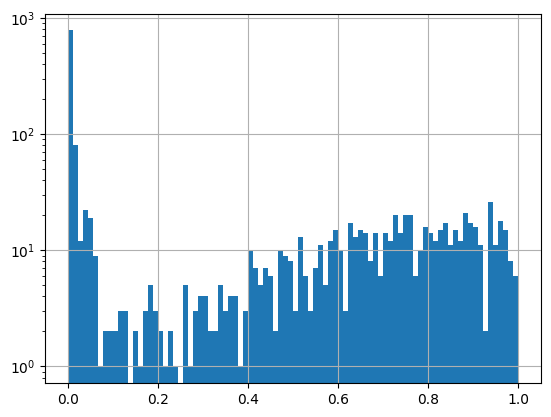

In [51]:
# Percentage of regions flagged histogram with y-axis in log scale
import matplotlib.pyplot as plt
plt.yscale('log')
qc_groups_rep['pct_regions_flagged'].hist(bins=90)

In [52]:
qc_groups_rep["max_rel_diff"].describe()

count    1611.000000
mean        0.940968
std         0.950710
min         0.000000
25%         0.153846
50%         0.266667
75%         1.831287
max         3.797402
Name: max_rel_diff, dtype: float64

<Axes: >

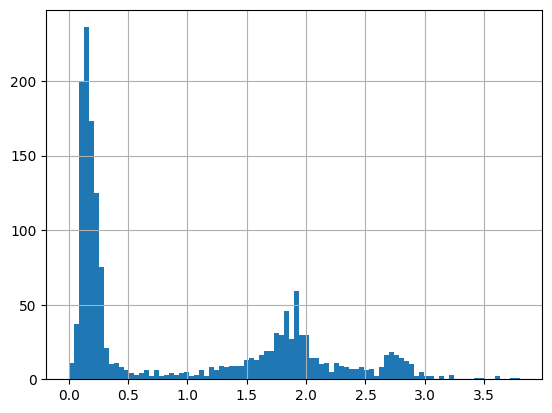

In [53]:
qc_groups_rep["max_rel_diff"].hist(bins=90)

In [54]:
qc_groups_rep["max_abs_diff"].describe()

count    1611.000000
mean      150.844412
std       236.006126
min         0.000000
25%         6.652850
50%        25.077000
75%       227.774000
max      1647.437900
Name: max_abs_diff, dtype: float64

In [55]:
from scipy.stats import zscore

def select_most_consistent(seg, qc_groups):
    """From segmentation dataframe and group-level QC dataframe,
    select the most consistent session per (OASISID, days) group
    based on z-scores against a reference distribution from n_sess=1 groups.
    
    Returns a filtered segmentation dataframe.
    """
    id_cols = ["OASISID", "days"]
    region_cols = seg.columns.difference(id_cols)

    # --- 1) Compute reference mean and std from n_sess=1 groups
    ref_groups = qc_groups.loc[qc_groups["n_sessions"] == 1, ["OASISID","days"]]
    seg_ref = seg.merge(ref_groups, on=id_cols)
    ref_mean = seg_ref[region_cols].mean()
    ref_std  = seg_ref[region_cols].std().replace(0, np.nan)  # avoid div by 0

    # --- 2) Compute z-scores for n_sess>1 groups
    rep_groups = qc_groups.loc[qc_groups["n_sessions"] > 1, ["OASISID","days"]]
    seg_rep = seg.merge(rep_groups, on=id_cols).copy()

    zscores = (seg_rep[region_cols] - ref_mean) / ref_std
    seg_rep["mean_abs_z"] = zscores.abs().median(axis=1)

    # --- 3) Keep the row with lowest mean_abs_z in each repeat group
    seg_best = (
        seg_rep.sort_values("mean_abs_z")
            .groupby(id_cols)
            .head(1)   # take best row per group
    )

    # Combine with n=1 groups for final dataset
    seg_final = pd.concat([seg_ref, seg_best], ignore_index=True)
    seg_final = seg_final.drop(columns=["mean_abs_z"], errors='ignore')
    seg_final = seg_final.sort_values(id_cols).reset_index(drop=True)
    return seg_final
seg = select_most_consistent(seg, qc_groups)
seg_thrs = select_most_consistent(seg_thrs, qc_groups_thrs)

In [56]:
seg

,OASISID,days,TIV,x3rdVentricle,x4thVentricle,RightAccumbensArea,LeftAccumbensArea,BrainStem,RightCaudate,LeftCaudate,RightCerebellumExterior,LeftCerebellumExterior,RightCerebralWhiteMatter,LeftCerebralWhiteMatter,CSF,RightInfLatVent,LeftInfLatVent,RightLateralVentricle,LeftLateralVentricle,RightPallidum,LeftPallidum,RightPutamen,LeftPutamen,RightVessel,LeftVessel,OpticChiasm,CerebellarVermalLobulesI0x2DV,CerebellarVermalLobulesVI0x2DVII,CerebellarVermalLobulesVIII0x2DX,LeftBasalForebrain,RightBasalForebrain,RightACgGAnteriorCingulateGyrus,LeftACgGAnteriorCingulateGyrus,RightAInsAnteriorInsula,LeftAInsAnteriorInsula,RightAOrGAnteriorOrbitalGyrus,LeftAOrGAnteriorOrbitalGyrus,RightAnGAngularGyrus,LeftAnGAngularGyrus,RightCalcCalcarineCortex,LeftCalcCalcarineCortex,RightCOCentralOperculum,LeftCOCentralOperculum,RightCunCuneus,LeftCunCuneus,RightEntEntorhinalArea,LeftEntEntorhinalArea,RightFOFrontalOperculum,LeftFOFrontalOperculum,RightFRPFrontalPole,LeftFRPFrontalPole,RightFuGFusiformGyrus,LeftFuGFusiformGyrus,RightGReGyrusRectus,LeftGReGyrusRectus,RightIOGInferiorOccipitalGyrus,LeftIOGInferiorOccipitalGyrus,RightITGInferiorTemporalGyrus,LeftITGInferiorTemporalGyrus,RightLiGLingualGyrus,LeftLiGLingualGyrus,RightLOrGLateralOrbitalGyrus,LeftLOrGLateralOrbitalGyrus,RightMCgGMiddleCingulateGyrus,LeftMCgGMiddleCingulateGyrus,RightMFCMedialFrontalCortex,LeftMFCMedialFrontalCortex,RightMFGMiddleFrontalGyrus,LeftMFGMiddleFrontalGyrus,RightMOGMiddleOccipitalGyrus,LeftMOGMiddleOccipitalGyrus,RightMOrGMedialOrbitalGyrus,LeftMOrGMedialOrbitalGyrus,RightMPoGPostcentralGyrusMedialSegment,LeftMPoGPostcentralGyrusMedialSegment,RightMPrGPrecentralGyrusMedialSegment,LeftMPrGPrecentralGyrusMedialSegment,RightMSFGSuperiorFrontalGyrusMedialSegment,LeftMSFGSuperiorFrontalGyrusMedialSegment,RightMTGMiddleTemporalGyrus,LeftMTGMiddleTemporalGyrus,RightOCPOccipitalPole,LeftOCPOccipitalPole,RightOFuGOccipitalFusiformGyrus,LeftOFuGOccipitalFusiformGyrus,RightOpIFGOpercularPartOfTheInferiorFrontalGyrus,LeftOpIFGOpercularPartOfTheInferiorFrontalGyrus,RightOrIFGOrbitalPartOfTheInferiorFrontalGyrus,LeftOrIFGOrbitalPartOfTheInferiorFrontalGyrus,RightPCgGPosteriorCingulateGyrus,LeftPCgGPosteriorCingulateGyrus,RightPCuPrecuneus,LeftPCuPrecuneus,RightPHGParahippocampalGyrus,LeftPHGParahippocampalGyrus,RightPInsPosteriorInsula,LeftPInsPosteriorInsula,RightPOParietalOperculum,LeftPOParietalOperculum,RightPoGPostcentralGyrus,LeftPoGPostcentralGyrus,RightPOrGPosteriorOrbitalGyrus,LeftPOrGPosteriorOrbitalGyrus,RightPPPlanumPolare,LeftPPPlanumPolare,RightPrGPrecentralGyrus,LeftPrGPrecentralGyrus,RightPTPlanumTemporale,LeftPTPlanumTemporale,RightSCASubcallosalArea,LeftSCASubcallosalArea,RightSFGSuperiorFrontalGyrus,LeftSFGSuperiorFrontalGyrus,RightSMCSupplementaryMotorCortex,LeftSMCSupplementaryMotorCortex,RightSMGSupramarginalGyrus,LeftSMGSupramarginalGyrus,RightSOGSuperiorOccipitalGyrus,LeftSOGSuperiorOccipitalGyrus,RightSPLSuperiorParietalLobule,LeftSPLSuperiorParietalLobule,RightSTGSuperiorTemporalGyrus,LeftSTGSuperiorTemporalGyrus,RightTMPTemporalPole,LeftTMPTemporalPole,RightTrIFGTriangularPartOfTheInferiorFrontalGyrus,LeftTrIFGTriangularPartOfTheInferiorFrontalGyrus,RightTTGTransverseTemporalGyrus,LeftTTGTransverseTemporalGyrus,LeftSTN,RightSTN,LeftSubstantiaNigra,RightSubstantiaNigra,LeftRedNucleus,RightRedNucleus,LeftDentateNucleus,RightDentateNucleus,LeftTh_anterior,RightTh_anterior,LeftTh_geniculate,RightTh_geniculate,LeftTh_mediodorsal,RightTh_mediodorsal,LeftTh_intralaminar,RightTh_intralaminar,LeftTh_pulvinar,RightTh_pulvinar,LeftTh_ventroanterior,RightTh_ventroanterior,LeftTh_ventrolateral,RightTh_ventrolateral,LeftTh_ventroposterior,RightTh_ventroposterior,LeftTh_posteriorAnterior,RightTh_posteriorAnterior,LeftAgd_astr,RightAgd_astr,LeftAgd_centromedian,RightAgd_centromedian,LeftAgd_laterobasal,RightAgd_laterobasal,LeftAgd_superficial,RightAgd_superficial,LeftHi_SPAM_CA10x2D3,RightHi_SPAM_CA10x2D3,LeftHi_SPAM_CA40x2DDG,RightHi_SPAM_CA40x2DDG,LeftHi_SPAM_su

In [57]:
seg_mean_pst, qc_regions_pst, qc_groups_pst = quality_control(seg)
seg_mean_thrs_pst, qc_regions_thrs_pst, qc_groups_thrs_pst = quality_control(seg_thrs)

In [58]:
qc_regions_thrs_pst['flag_divergent'].value_counts()

flag_divergent
False    583331
Name: count, dtype: int64

<Axes: >

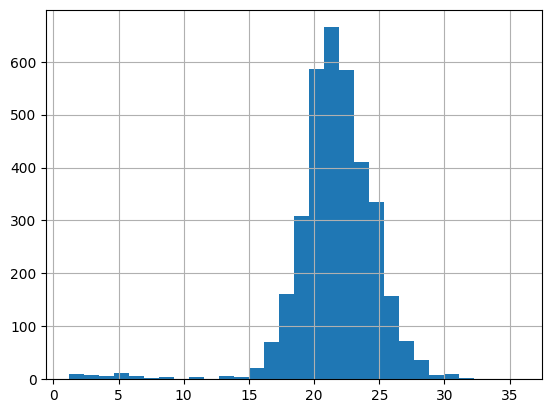

In [59]:
seg['BrainStem'].hist(bins=30)

# Matching with new ROI names

In [60]:
len(seg.columns.to_list()[3:])

166

In [66]:
import pandas as pd
ex = pd.read_csv("data/sPR04383_NS300459-0011-00001-000176-01_T1w_NM-val-gen_regions_summary.csv", sep=";")
ex['nospace_name'] = seg.columns.to_list()[3:]
ex = move_column(ex, "nospace_name", 1)
ex = ex.rename(columns={"name": "space_name"})
#ex # after manual inspection -> both old and new ROI names match

In [67]:
ex

,space_name,nospace_name,index,GMvalues_unthresholded,GMvalues_thresholded
0,3rd Ventricle,x3rdVentricle,4,1.070000,0.180000
1,4th Ventricle,x4thVentricle,11,1.924000,0.000000
2,Right Accumbens Area,RightAccumbensArea,23,0.292000,0.292000
3,Left Accumbens Area,LeftAccumbensArea,30,0.348000,0.348000
4,Brain Stem,BrainStem,35,20.362999,0.493000
5,Right Caudate,RightCaudate,36,2.060000,1.990000
6,Left Caudate,LeftCaudate,37,2.138000,2.079000
7,Right Cerebellum Exterior,RightCerebellumExterior,38,54.857997,38.341998
8,Left Cerebellum Exterior,LeftCerebellumExterior,39,56.599997,38.723998
9,Right Cerebral White Matter,RightCerebralWhiteMatter,44,183.634991,8.760000


In [70]:
ex[["nospace_name", "space_name"]].to_csv("data/roi_rename_map.csv", index=False)

In [68]:
# build mapping dictionary
seg_rename_map = dict(zip(ex["nospace_name"], ex["space_name"]))

# apply rename to seg dataframe
seg = seg.rename(columns=seg_rename_map)
seg_thrs = seg_thrs.rename(columns=seg_rename_map)

In [69]:
seg.columns

Index(['OASISID', 'days', 'TIV', '3rd Ventricle', '4th Ventricle',
       'Right Accumbens Area', 'Left Accumbens Area', 'Brain Stem',
       'Right Caudate', 'Left Caudate',
       ...
       'Left agd_laterobasal', 'Right agd_laterobasal', 'Left agd_superficial',
       'Right agd_superficial', 'Left hi_SPAM_CA1-3', 'Right hi_SPAM_CA1-3',
       'Left hi_SPAM_CA4-DG', 'Right hi_SPAM_CA4-DG', 'Left hi_SPAM_subiculum',
       'Right hi_SPAM_subiculum'],
      dtype='object', length=169)

# Clinical score (CDR) csv

CDRSUM is the sum of all box scores from the individual domains of the CDR scale. The scale has six domains: memory, orientation, judgment and problem-solving, community affairs, home and hobbies, and personal care. Each domain is rated from 0 to 3 or 0.5, with higher scores indicating more severe impairment. The CDRSUM is calculated by adding the scores from all six of these domains. This provides a detailed and nuanced picture of a person's cognitive and functional impairment across different areas of life. It's often used in research as a continuous variable to measure the progression of dementia over time.
CDRTOT is the overall global score of the CDR scale, representing a single, comprehensive rating of a person's dementia severity. This score is not a simple sum but is determined by a specific algorithm based on the individual domain scores. It ranges from 0 (no dementia) to 3 (severe dementia) and can include a 0.5 for very mild dementia. The CDRTOT is a categorical variable used for clinical diagnosis and to classify subjects into distinct groups, such as cognitively normal (CDR 0), very mild cognitive impairment (CDR 0.5), or mild dementia (CDR 1).   

The primary difference is that CDRSUM is a summation of individual domain scores, providing a more granular and continuous measure of impairment, while CDRTOT is a global, categorical score used for a summary diagnosis. CDRSUM gives a richer picture of a patient's deficits across different cognitive and functional areas, making it useful for tracking subtle changes in research. In contrast, CDRTOT provides a single, clinically meaningful classification of dementia severity, which is more directly applicable for diagnosis and clinical staging.

In [29]:
cdr_r3 = pd.read_csv("./data/OASIS3/OASIS3_UDSb4_cdr.csv")
cdr_r4 = pd.read_csv("./data/OASIS4/OASIS4_data_files/scans/CDR-OASIS4_data_CDR/resources/csv/files/OASIS4_data_CDR.csv")

In [30]:
cdr_r4 = cdr_r4.rename(columns={"oasis_id": "OASISID", "visit_days": "days_to_visit", "cdr": "CDRTOT"})

In [31]:
overlap = set(cdr_r3['OASISID']).intersection(cdr_r4['OASISID'])

if overlap:
    print("Not mutually exclusive. Overlap found:", overlap)
else:
    print("Mutually exclusive. No overlap.")


Mutually exclusive. No overlap.


In [48]:
cdr_r3.columns

Index(['OASISID', 'OASIS_session_label', 'days_to_visit', 'age at visit',
       'MMSE', 'memory', 'orient', 'judgment', 'commun', 'homehobb',
       'perscare', 'CDRSUM', 'CDRTOT', 'dx1_code', 'dx2_code', 'dx3_code',
       'dx4_code', 'dx5_code', 'dx1', 'dx2', 'dx3', 'dx4', 'dx5'],
      dtype='object')

In [32]:
cdr_r3

,OASISID,OASIS_session_label,days_to_visit,age at visit,MMSE,memory,orient,judgment,commun,homehobb,perscare,CDRSUM,CDRTOT,dx1_code,dx2_code,dx3_code,dx4_code,dx5_code,dx1,dx2,dx3,dx4,dx5
0,OAS30001,OAS30001_UDSb4_d0000,0,65.19,28.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,Cognitively normal,.,.,.,.
1,OAS30001,OAS30001_UDSb4_d0339,339,66.12,28.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,Cognitively normal,.,.,.,.
2,OAS30001,OAS30001_UDSb4_d0722,722,67.17,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,Cognitively normal,.,.,.,.
3,OAS30001,OAS30001_UDSb4_d1106,1106,68.22,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,Cognitively normal,.,.,.,.
4,OAS30001,OAS30001_UDSb4_d1456,1456,69.18,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,Cognitively normal,.,.,.,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8621,OAS31472,OAS31472_UDSb4_d0826,826,69.53,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,Cognitively normal,A,A,A,A
8622,OAS31473,OAS31473_UDSb4_d0000,0,56.61,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,Cognitively normal,A,A,A,A
8623,OAS31473,OAS31473_UDSb4_d1142,1142,59.74,NaN,0.5,0.0,0.0,0.0,0.0,0.0,0.5,0.5,2.0,NaN,NaN,NaN,NaN,uncertain dementia,A,A,A,A
8624,OAS31474,OAS31474_UDSb4_d0000,0,81.84,22.0,0.5,0.0,0.0,0.0,0.0,0.0,0.5,0.5,150.0,NaN,NaN,NaN,NaN,0.5 in memory only,A,A,A,A


In [33]:
cdr_r4

,OASISID,cdr_id,days_to_visit,memory,orient,judgement,community,homehobb,perscare,sumbox,CDRTOT
0,OAS42000,OAS42000_CDR_d3000,3000,0.5,0.0,0.0,0.5,0.5,0.0,1.5,0.5
1,OAS42001,OAS42001_CDR_d3392,3392,1.0,0.5,0.5,0.5,0.0,0.0,2.5,0.5
2,OAS42001,OAS42001_CDR_d3000,3000,0.5,0.0,0.5,0.5,1.0,0.0,2.5,0.5
3,OAS42001,OAS42001_CDR_d3203,3203,0.5,1.0,1.0,0.5,0.5,0.0,3.5,0.5
4,OAS42002,OAS42002_CDR_d3000,3000,0.5,0.5,0.5,0.5,0.5,1.0,3.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...
1153,OAS42724,OAS42724_CDR_d3378,3378,0.5,0.5,0.0,0.0,0.0,0.0,1.0,0.5
1154,OAS42725,OAS42725_CDR_d3420,3420,0.0,0.5,0.0,0.0,0.0,0.0,0.5,0.5
1155,OAS42725,OAS42725_CDR_d3819,3819,0.5,0.5,0.5,0.5,0.0,0.0,2.0,0.5
1156,OAS42726,OAS42726_CDR_d3000,3000,0.0,0.0,0.5,0.5,0.0,0.0,1.0,0.5


In [45]:
print(cdr_r3['CDRTOT'].value_counts(normalize=True).sort_index())
print(cdr_r4['CDRTOT'].value_counts(normalize=True).sort_index())

CDRTOT
0.0    0.751188
0.5    0.167420
1.0    0.061217
2.0    0.017971
3.0    0.002203
Name: proportion, dtype: float64
CDRTOT
0.0    0.088850
0.5    0.569686
1.0    0.256098
2.0    0.083624
3.0    0.001742
Name: proportion, dtype: float64


<Axes: >

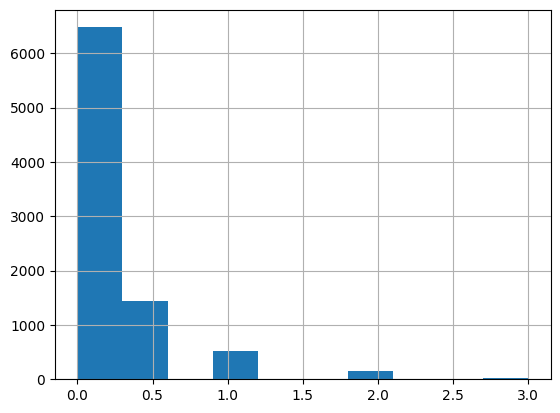

In [47]:
cdr_r3['CDRTOT'].hist(bins=10)

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- Setup ----------
_cdr_order = [0, 0.5, 1, 2, 3]
df = cdr_r3.copy()
df["CDRTOT"] = pd.Categorical(df["CDRTOT"], categories=_cdr_order, ordered=True)

sns.set(context="talk", style="whitegrid")

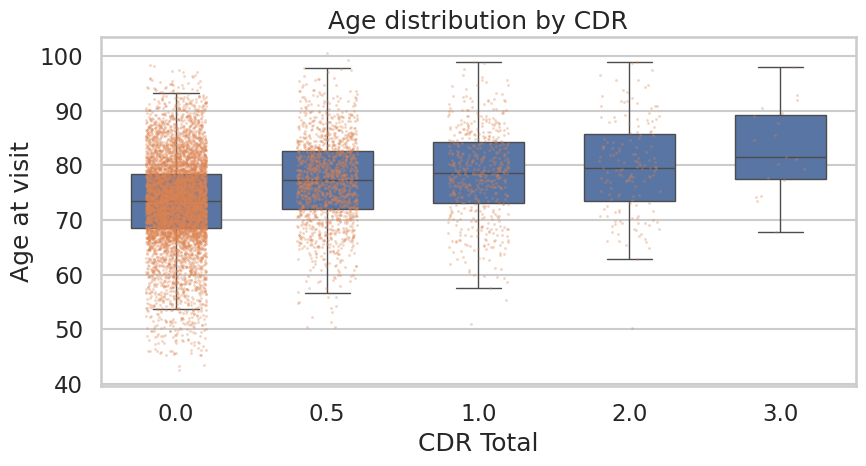

In [50]:
plt.figure(figsize=(9,5))
ax = sns.boxplot(
    data=df, x="CDRTOT", y="age at visit",
    showfliers=False, width=0.6
)
sns.stripplot(
    data=df, x="CDRTOT", y="age at visit",
    dodge=False, jitter=0.2, size=2, alpha=0.35
)
ax.set(title="Age distribution by CDR", xlabel="CDR Total", ylabel="Age at visit")
plt.tight_layout()


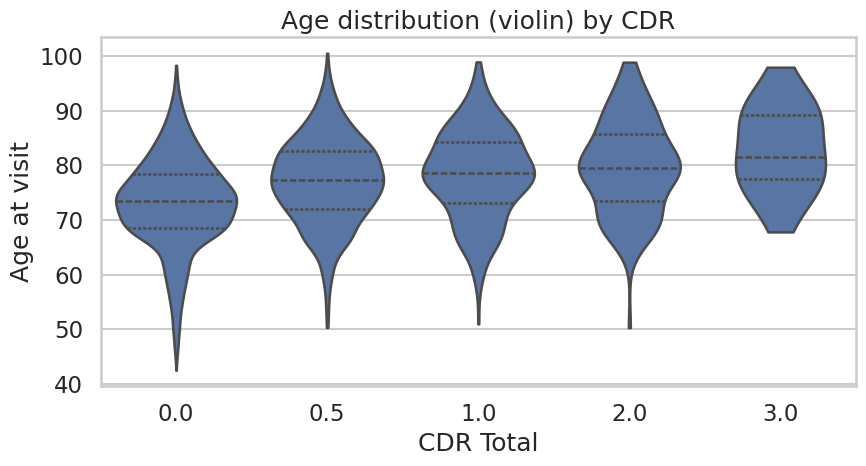

In [51]:
plt.figure(figsize=(9,5))
ax = sns.violinplot(
    data=df, x="CDRTOT", y="age at visit",
    inner="quartile", cut=0
)
ax.set(title="Age distribution (violin) by CDR", xlabel="CDR Total", ylabel="Age at visit")
plt.tight_layout()


In [34]:
cdr_r = pd.concat([cdr_r3, cdr_r4], ignore_index=True)

In [35]:
cdr_r = cdr_r.dropna(subset=["OASISID", "days_to_visit", "CDRTOT"])

In [36]:
cdr_r["AD"] = cdr_r["CDRTOT"].apply(lambda x: 1 if x > 0 else 0)

<Axes: xlabel='age at visit', ylabel='Count'>

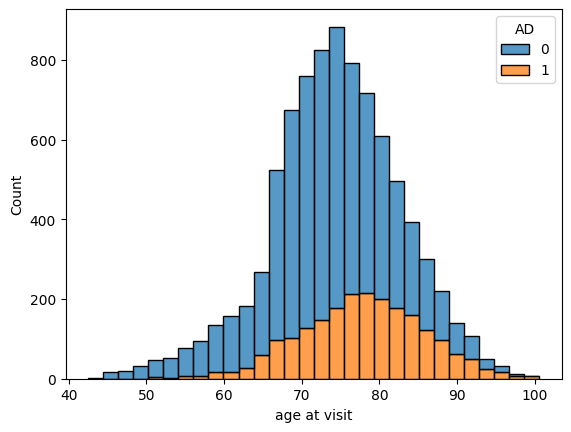

In [37]:
import seaborn as sns

sns.histplot(cdr_r, x="age at visit", hue="AD", multiple="stack", bins=30)

In [52]:
cdr_r["OASISID"].nunique()

2026

In [53]:
cdr_r["CDRTOT"].value_counts(dropna=False)

CDRTOT
0.0    6580
0.5    2095
1.0     822
2.0     251
3.0      21
Name: count, dtype: int64

In [54]:
cdr_r['AD'] = cdr_r['CDRTOT'].apply(lambda x: 1 if x > 0 else 0)

In [55]:
cdr_r.isna().sum().sort_values(ascending=False) 
# OASISID, days_to_visit, CDRTOT have 0 missing values, no need to filter

dx5_code               9704
dx4_code               9521
dx3_code               8888
sumbox                 8663
judgement              8655
community              8653
cdr_id                 8621
dx2_code               6746
MMSE                   2178
dx1_code               1309
commun                 1153
judgment               1153
CDRSUM                 1153
OASIS_session_label    1148
age at visit           1148
dx1                    1148
dx2                    1148
dx3                    1148
dx4                    1148
dx5                    1148
perscare                 42
orient                   40
homehobb                 37
memory                   36
OASISID                   0
CDRTOT                    0
days_to_visit             0
AD                        0
dtype: int64

CDRSUM
0.0     6251
0.5      449
1.0      299
1.5      229
2.5      187
2.0      164
3.0      117
5.0      114
3.5      112
4.0      110
4.5      106
6.0       90
8.0       68
7.0       63
5.5       48
10.0      41
11.0      39
9.0       37
12.0      34
13.0      11
14.0       9
6.5        8
18.0       8
7.5        6
15.0       5
16.0       5
17.0       3
8.5        2
9.5        1
Name: count, dtype: int64


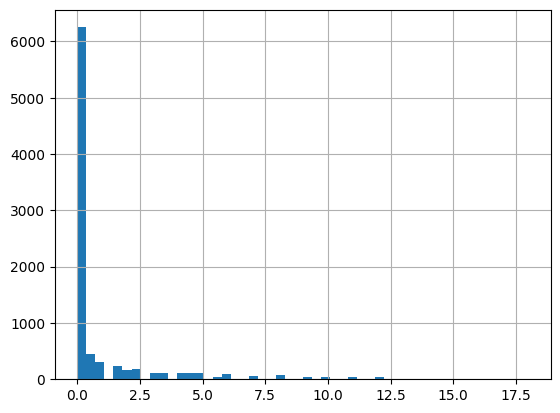

In [56]:
cdr_r["CDRSUM"].hist(bins=50)
print(cdr_r["CDRSUM"].value_counts())

In [57]:
#cdr_r["CDRTOT"].hist(bins=5)
print(cdr_r["CDRTOT"].value_counts())
print(cdr_r["CDRTOT"].value_counts(normalize=True))

CDRTOT
0.0    6580
0.5    2095
1.0     822
2.0     251
3.0      21
Name: count, dtype: int64
CDRTOT
0.0    0.673559
0.5    0.214454
1.0    0.084144
2.0    0.025694
3.0    0.002150
Name: proportion, dtype: float64


In [58]:
cdr_r[cdr_r["days_to_visit"] < 0]

,OASISID,OASIS_session_label,days_to_visit,age at visit,MMSE,memory,orient,judgment,commun,homehobb,perscare,CDRSUM,CDRTOT,dx1_code,dx2_code,dx3_code,dx4_code,dx5_code,dx1,dx2,dx3,dx4,dx5,cdr_id,judgement,community,sumbox,AD


In [59]:
cdr_r = cdr_r[cdr_r["days_to_visit"] >= 0]

<Axes: >

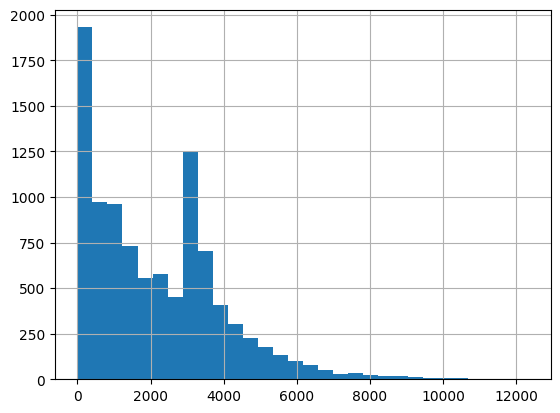

In [60]:
cdr_r["days_to_visit"].hist(bins=30)

In [61]:
cdr = cdr_r.copy()[["OASISID", "days_to_visit", "CDRTOT"]]
cdr = cdr.rename(columns={"days_to_visit": "days"})
cdr

,OASISID,days,CDRTOT
0,OAS30001,0,0.0
1,OAS30001,339,0.0
2,OAS30001,722,0.0
3,OAS30001,1106,0.0
4,OAS30001,1456,0.0
...,...,...,...
9779,OAS42724,3378,0.5
9780,OAS42725,3420,0.5
9781,OAS42725,3819,0.5
9782,OAS42726,3000,0.5


# Unifiying SEG (X) and CDR (Y)

For each seg (~4000 rows), we match it with the closest 365-days cdr datapoint (close) or the highest CDR score (bias). One-to-one match, no multiple matches allowed for cdr. We lose a little bit of CDR variability but it is safer (can hurt performance).

In [64]:
nmm = pd.read_csv("./data/neuromorphometrics.csv")

In [65]:
nmm

,region,left_id,right_id,midline_id,lobe,ca_network,left_full_name,right_full_name,midline_full_name,acronym,lobe_color,region_color
0,3rdVentricle,NaN,NaN,4.0,Ventricles and CSF,NaN,NaN,NaN,x3rdVentricle_4,3rdVent,#17becf,#ffa0be
1,4thVentricle,NaN,NaN,11.0,Ventricles and CSF,NaN,NaN,NaN,x4thVentricle_11,4thVent,#17becf,#32db93
2,ACgGAnteriorCingulateGyrus,101.0,100.0,NaN,Frontal Lobe,Cingulo-Opercular,LeftACgGAnteriorCingulateGyrus_101,RightACgGAnteriorCingulateGyrus_100,NaN,ACgG,#bcbd22,#00ff00
3,AInsAnteriorInsula,103.0,102.0,NaN,Insular Cortex,Cingulo-Opercular,LeftAInsAnteriorInsula_103,RightAInsAnteriorInsula_102,NaN,AIns,#d62728,#75bd32
4,AOrGAnteriorOrbitalGyrus,105.0,104.0,NaN,Frontal Lobe,Orbito-Affective,LeftAOrGAnteriorOrbitalGyrus_105,RightAOrGAnteriorOrbitalGyrus_104,NaN,AOrG,#bcbd22,#ff00ff
5,AccumbensArea,30.0,23.0,NaN,Subcortical Structures,NaN,LeftAccumbensArea_30,RightAccumbensArea_23,NaN,Acc,#e377c2,#032cfe
6,Agd_laterobasal,238.0,239.0,NaN,Limbic Cortex,NaN,LeftAgd_laterobasal_238,RightAgd_laterobasal_239,NaN,Agd_lb,#1f77b4,#7dfa86
7,Agd_superficial,240.0,241.0,NaN,Limbic Cortex,NaN,LeftAgd_superficial_240,RightAgd_superficial_241,NaN,Agd_sp,#1f77b4,#ffff80
8,AnGAngularGyrus,107.0,106.0,NaN,Parietal Lobe,Default,LeftAnGAngularGyrus_107,RightAnGAngularGyrus_106,NaN,AnG,#9467bd,#800000
9,BasalForebrain,75.0,76.0,NaN,Subcortical Structures,NaN,LeftBasalForebrain_75,RightBasalForebrain_76,NaN,BF,#e377c2,#09f8c0


In [66]:
nmm[nmm['lobe'] == 'Ventricles and CSF']

,region,left_id,right_id,midline_id,lobe,ca_network,left_full_name,right_full_name,midline_full_name,acronym,lobe_color,region_color
0,3rdVentricle,NaN,NaN,4.0,Ventricles and CSF,NaN,NaN,NaN,x3rdVentricle_4,3rdVent,#17becf,#ffa0be
1,4thVentricle,NaN,NaN,11.0,Ventricles and CSF,NaN,NaN,NaN,x4thVentricle_11,4thVent,#17becf,#32db93
12,CSF,NaN,NaN,46.0,Ventricles and CSF,NaN,NaN,NaN,CSF_46,CSF,#17becf,#000000
32,InfLatVent,50.0,49.0,NaN,Ventricles and CSF,NaN,LeftInfLatVent_50,RightInfLatVent_49,NaN,ILV,#17becf,#000000
34,LateralVentricle,52.0,51.0,NaN,Ventricles and CSF,NaN,LeftLateralVentricle_52,RightLateralVentricle_51,NaN,LV,#17becf,#000000
48,OpticChiasm,NaN,NaN,69.0,Ventricles and CSF,NaN,NaN,NaN,OpticChiasm_69,OC,#17becf,#000000


In [67]:
nmm[nmm['lobe'] == 'Ventricles and CSF']['region'].to_list()

['3rdVentricle',
 '4thVentricle',
 'CSF',
 'InfLatVent',
 'LateralVentricle',
 'OpticChiasm']

In [72]:
# manually retrieving ventricle and CSF region names from segmentation csv since
# they don't fit neuromorphometrics nomenclature exactly
vent_csf_region_names = [
    '3rd Ventricle',
    '4th Ventricle',
    'CSF',
    'Right Inf Lat Vent',
    'Left Inf Lat Vent',
    'Right Lateral Ventricle',
    'Left Lateral Ventricle',
    'Optic Chiasm',
]

In [73]:
seg.columns.to_list()

['OASISID',
 'days',
 'TIV',
 '3rd Ventricle',
 '4th Ventricle',
 'Right Accumbens Area',
 'Left Accumbens Area',
 'Brain Stem',
 'Right Caudate',
 'Left Caudate',
 'Right Cerebellum Exterior',
 'Left Cerebellum Exterior',
 'Right Cerebral White Matter',
 'Left Cerebral White Matter',
 'CSF',
 'Right Inf Lat Vent',
 'Left Inf Lat Vent',
 'Right Lateral Ventricle',
 'Left Lateral Ventricle',
 'Right Pallidum',
 'Left Pallidum',
 'Right Putamen',
 'Left Putamen',
 'Right vessel',
 'Left vessel',
 'Optic Chiasm',
 'Cerebellar Vermal Lobules I-V',
 'Cerebellar Vermal Lobules VI-VII',
 'Cerebellar Vermal Lobules VIII-X',
 'Left Basal Forebrain',
 'Right Basal Forebrain',
 'Right ACgG anterior cingulate gyrus',
 'Left ACgG anterior cingulate gyrus',
 'Right AIns anterior insula',
 'Left AIns anterior insula',
 'Right AOrG anterior orbital gyrus',
 'Left AOrG anterior orbital gyrus',
 'Right AnG angular gyrus',
 'Left AnG angular gyrus',
 'Right Calc calcarine cortex',
 'Left Calc calcarine c

In [83]:
def preprocess_df(df, num_cats):
    df.rename(columns={"days_cdr": "cdr_days"}, inplace=True)
    df.rename(columns={"days": "seg_days"}, inplace=True)

    df = move_column(df, "CDRTOT", 3)

    df = move_column(df, "cdr_days", 2)

    df['cdr_days'] = df['cdr_days'].astype('Int64')
    df['delta_days'] = (df['cdr_days'] - df['seg_days']).abs()

    df = move_column(df, "delta_days", 3)

    df = df.dropna(subset=["CDRTOT"])

    if num_cats == 2:
        # 0 = no_CI, 1 = CI
        df["CDR"] = df["CDRTOT"].apply(lambda x: "CN" if x == 0 else "AD")

    elif num_cats == 3:
        # 0 = no_CI, 0.5 = MCI, 1/2/3 = AD
        def map_cdr(x):
            if x == 0:
                return "CN"
            elif x == 0.5:
                return "MCI"
            else:
                return "AD"
        df["CDR"] = df["CDRTOT"].apply(map_cdr)

    else:
        raise ValueError("num_cats must be 2 or 3")

    df = move_column(df, "CDR", 4)  

    return df

def normalize_tiv(df):
    df = df.copy()
    # Identify voxel count columns (exclude ID, label, and target columns)
    voxel_cols = [c for c in df.columns if c not in ["OASISID", "seg_days", "cdr_days", "delta_days", "CDRTOT", "CDR", "TIV"]]

    # Normalize by TIV
    for col in voxel_cols:
        df[col] = df[col] / df["TIV"]

    df = df.drop(columns=["TIV"])
    return df

def drop_tiv(df):
    return df.drop(columns=["TIV"]).copy()

import numpy as np

from scipy.stats import zscore

def filter_outliers(df, sigma, allowed_outliers):
    voxel_cols = [c for c in df.columns if c not in ["OASISID", "seg_days", "cdr_days", "delta_days", "CDRTOT", "CDR", "TIV"]]
    if not voxel_cols:
        print("⚠️ No voxel_count columns found, skipping filtering")
        return df
    
    zscores = df[voxel_cols].apply(zscore, nan_policy="omit")
    max_z = zscores.abs().max().max()
    #print(f"  max|z|={max_z:.3f}")

    outlier_counts = (zscores.abs() > sigma).sum(axis=1)
    #print(outlier_counts.value_counts().sort_index())
    mask = outlier_counts <= allowed_outliers

    return df[mask].copy()

def add_dfs(dfs, seg, threshold, num_cats=3, sigma=None, allowed_outliers=None, vent_csf=False):
    # copy seg to df
    df = seg.copy()

    if not vent_csf:
        df = df.drop(columns=vent_csf_region_names, errors="ignore")

    # optional filtering
    if sigma is not None and allowed_outliers is not None:
        df = filter_outliers(df, sigma, allowed_outliers)

    # merge seg and cdr on OASISID
    merged = df.merge(cdr, on="OASISID", suffixes=("", "_cdr"))

    # keep only rows where days are within ±365
    merged = merged[merged.apply(lambda x: abs(x["days"] - x["days_cdr"]) <= 365, axis=1)]

    # DF CLOSE ====================================================================
    # if multiple matches exist, keep the closest one
    merged_close = merged.loc[merged.groupby(["OASISID", "days"])["days_cdr"].apply(
        lambda x: (abs(x - x.name[1])).idxmin()
    )]

    # bring columns back into df
    df_close = df.merge(
        merged_close[["OASISID", "days", "CDRTOT", "days_cdr"]],
        on=["OASISID", "days"],
        how="left"
    )
    df_close = preprocess_df(df_close, num_cats=num_cats)

    dfs.add(
        drop_tiv(df_close), 
        threshold=threshold, 
        linking="closest", 
        tiv_norm=False, 
        num_cats=num_cats, 
        sigma=sigma, 
        allowed_outliers=allowed_outliers, 
        vent_csf=vent_csf)
    dfs.add(
        normalize_tiv(df_close), 
        threshold=threshold, 
        linking="closest", 
        tiv_norm=True, 
        num_cats=num_cats, 
        sigma=sigma, 
        allowed_outliers=allowed_outliers, 
        vent_csf=vent_csf)


    # DF BIAS =====================================================================

    # if multiple matches exist, keep the one with highest CDRTOT, breaking ties by closest date
    merged_bias = merged.sort_values(
        ["OASISID", "days", "CDRTOT", "days_cdr"],
        ascending=[True, True, False, True]
    ).groupby(["OASISID", "days"], as_index=False).first()

    # bring columns back into df
    df_bias = df.merge(
        merged_bias[["OASISID", "days", "CDRTOT", "days_cdr"]],
        on=["OASISID", "days"],
        how="left"
    )
    df_bias = preprocess_df(df_bias, num_cats=num_cats)

    dfs.add(
        drop_tiv(df_bias), 
        threshold=threshold, 
        linking="bias", 
        tiv_norm=False, 
        num_cats=num_cats, 
        sigma=sigma, 
        allowed_outliers=allowed_outliers,
        vent_csf=vent_csf)
    dfs.add(
        normalize_tiv(df_bias), 
        threshold=threshold, 
        linking="bias", 
        tiv_norm=True, 
        num_cats=num_cats, 
        sigma=sigma, 
        allowed_outliers=allowed_outliers,
        vent_csf=vent_csf)

    
    return dfs

In [84]:
import os
import pickle

# Default save path
dfs_path = "data/dfs.pkl"

if os.path.exists(dfs_path):
    print(f"Loading existing DFStruct from {dfs_path}")
    with open(dfs_path, "rb") as f:
        dfs = pickle.load(f)
else:
    print("No existing DFStruct found — building from scratch.")
    dfs = DFStruct()

    for vent_csf in (True, False):
        if vent_csf:
            print("Including ventricle and CSF regions")
        else:
            print("Excluding ventricle and CSF regions")
        for sigma in (None, 3, 4, 5):
            for allowed_outliers in (None, 5, 10, 20):
                # keep sigma/allowed_outliers paired
                if (sigma is None) != (allowed_outliers is None):
                    continue

                for num_cats in (2, 3):
                    dfs = add_dfs(
                        dfs, seg,
                        threshold=False,
                        num_cats=num_cats,
                        sigma=sigma,
                        allowed_outliers=allowed_outliers,
                        vent_csf=vent_csf
                    )
                    dfs = add_dfs(
                        dfs, seg_thrs,
                        threshold=True,
                        num_cats=num_cats,
                        sigma=sigma,
                        allowed_outliers=allowed_outliers,
                        vent_csf=vent_csf
                    )

                if sigma is None and allowed_outliers is None:
                    unfiltered_rows = dfs(
                        threshold=False, linking="bias", tiv_norm=True,
                        num_cats=3, sigma=None, allowed_outliers=None, vent_csf=vent_csf
                    ).shape[0]
                    unfiltered_rows_thrs = dfs(
                        threshold=True, linking="bias", tiv_norm=True,
                        num_cats=3, sigma=None, allowed_outliers=None, vent_csf=vent_csf
                    ).shape[0]

                filtered_rows = dfs(
                    threshold=False, linking="bias", tiv_norm=True,
                    num_cats=3, sigma=sigma, allowed_outliers=allowed_outliers, vent_csf=vent_csf
                ).shape[0]
                print(f"Unthresholded,\tsigma={sigma},\tallowed_outliers={allowed_outliers},\tdropped={unfiltered_rows-filtered_rows} ({1-(filtered_rows/unfiltered_rows):.1%})")

                filtered_rows_thrs = dfs(
                    threshold=True, linking="bias", tiv_norm=True,
                    num_cats=3, sigma=sigma, allowed_outliers=allowed_outliers, vent_csf=vent_csf
                ).shape[0]
                print(f"Thresholded,\tsigma={sigma},\tallowed_outliers={allowed_outliers},\tdropped={unfiltered_rows_thrs-filtered_rows_thrs} ({1-(filtered_rows_thrs/unfiltered_rows_thrs):.1%})")

    # Save to disk for next runs
    with open(dfs_path, "wb") as f:
        pickle.dump(dfs, f)
    print(f"DFStruct saved to {dfs_path}")


No existing DFStruct found — building from scratch.
Including ventricle and CSF regions


Unthresholded,	sigma=None,	allowed_outliers=None,	dropped=0 (0.0%)
Thresholded,	sigma=None,	allowed_outliers=None,	dropped=0 (0.0%)
Unthresholded,	sigma=3,	allowed_outliers=5,	dropped=219 (6.5%)
Thresholded,	sigma=3,	allowed_outliers=5,	dropped=191 (5.7%)
Unthresholded,	sigma=3,	allowed_outliers=10,	dropped=142 (4.2%)
Thresholded,	sigma=3,	allowed_outliers=10,	dropped=140 (4.2%)
Unthresholded,	sigma=3,	allowed_outliers=20,	dropped=84 (2.5%)
Thresholded,	sigma=3,	allowed_outliers=20,	dropped=109 (3.3%)
Unthresholded,	sigma=4,	allowed_outliers=5,	dropped=121 (3.6%)
Thresholded,	sigma=4,	allowed_outliers=5,	dropped=108 (3.2%)
Unthresholded,	sigma=4,	allowed_outliers=10,	dropped=74 (2.2%)
Thresholded,	sigma=4,	allowed_outliers=10,	dropped=74 (2.2%)
Unthresholded,	sigma=4,	allowed_outliers=20,	dropped=59 (1.8%)
Thresholded,	sigma=4,	allowed_outliers=20,	dropped=51 (1.5%)
Unthresholded,	sigma=5,	allowed_outliers=5,	dropped=89 (2.7%)
Thresholded,	sigma=5,	allowed_outliers=5,	dropped=55 (1.6%)

In [85]:
df = dfs(threshold=False, linking="bias", tiv_norm=True, num_cats=3, sigma=3, allowed_outliers=20, vent_csf=True)
print(df.shape)
print(df["CDR"].value_counts())

(3265, 172)
CDR
CN     2078
MCI     793
AD      394
Name: count, dtype: int64


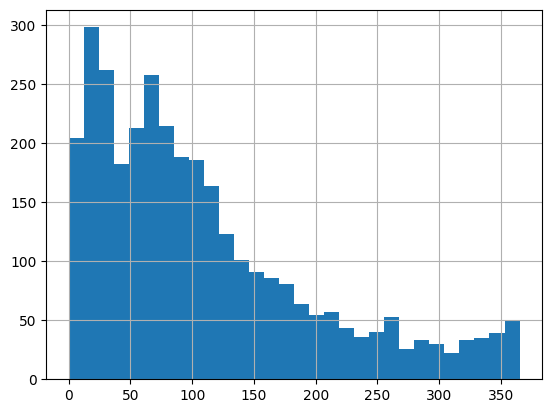

<Axes: >

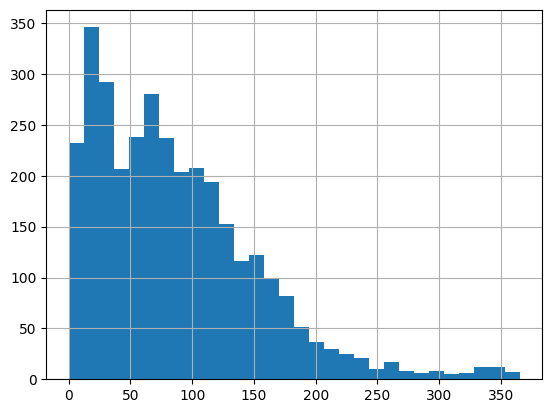

In [86]:
import matplotlib.pyplot as plt

dfs(threshold=False, linking="bias", tiv_norm=True, num_cats=3, sigma=3, allowed_outliers=20, vent_csf=True)['delta_days'].hist(bins=30)
plt.show()
dfs(threshold=False, linking="closest", tiv_norm=True, num_cats=3, sigma=3, allowed_outliers=20, vent_csf=True)['delta_days'].hist(bins=30)

In [87]:
print(dfs(threshold=False, linking="bias", tiv_norm=True, num_cats=3, sigma=3, allowed_outliers=20, vent_csf=True)["CDRTOT"].value_counts())
print(dfs(threshold=False, linking="closest", tiv_norm=True, num_cats=3, sigma=3, allowed_outliers=20, vent_csf=True)["CDRTOT"].value_counts())

CDRTOT
0.0    2078
0.5     793
1.0     318
2.0      74
3.0       2
Name: count, dtype: int64
CDRTOT
0.0    2150
0.5     797
1.0     268
2.0      49
3.0       1
Name: count, dtype: int64


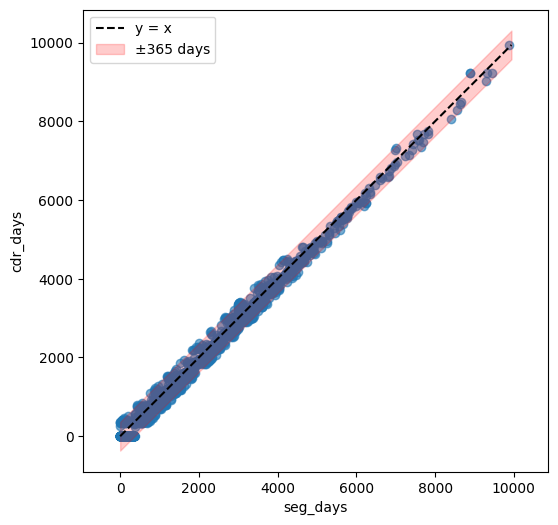

In [88]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))
plot_df = dfs(threshold=False, linking="bias", tiv_norm=True, num_cats=3, sigma=3, allowed_outliers=20, vent_csf=True).dropna(subset=["seg_days", "cdr_days"])
plt.scatter(plot_df["seg_days"], plot_df["cdr_days"], alpha=0.6)

# plot diagonal y = x
lims = [
    min(plot_df["seg_days"].min(), plot_df["cdr_days"].min()),
    max(plot_df["seg_days"].max(), plot_df["cdr_days"].max())
]
plt.plot(lims, lims, 'k--', label="y = x")

# add tolerance band ±365
plt.fill_between(
    lims,
    np.array(lims) - 365,
    np.array(lims) + 365,
    color="red",
    alpha=0.2,
    label="±365 days"
)

plt.xlabel("seg_days")
plt.ylabel("cdr_days")
plt.legend()
plt.axis("equal")
plt.show()

In [89]:
mask = (dfs(threshold=False, linking="bias", tiv_norm=True, num_cats=3,  sigma=3, allowed_outliers=20, vent_csf=True)["cdr_days"] 
        - dfs(threshold=False, linking="bias", tiv_norm=True, num_cats=3, sigma=3, allowed_outliers=20, vent_csf=True)["seg_days"]).abs() <= 365
all_within = mask.all()   # True if all rows satisfy condition
any_outside = (~mask).any()  # True if any row violates condition

print("All within 365 days:", all_within)
print("Any outside 365 days:", any_outside)

All within 365 days: True
Any outside 365 days: False
